# Customer Churn & Retention Intelligence System

## Phase 1 — Data Understanding and Exploratory Data Analysis

### Business Objective

The objective of this project is to identify customers who are at risk of becoming inactive based on their historical purchasing behaviour.

The resulting churn-risk predictions can support targeted customer retention strategies and help businesses prioritise high-risk, high-value customers.

## Dataset

The project uses the publicly available Online Retail II dataset from the UCI Machine Learning Repository.

The dataset contains transaction-level records from a UK-based online retail business.

In [29]:
#Imports
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
#Project paths
PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

RAW_DATA_DIR

WindowsPath('c:/Users/ptbha/OneDrive/Desktop/customer-churn-retention-intelligence/data/raw')

In [31]:
#Locate workbook and inspect sheets
excel_file = RAW_DATA_DIR / "online_retail_II.xlsx"

workbook = pd.ExcelFile(excel_file)

workbook.sheet_names

['Year 2009-2010', 'Year 2010-2011']

In [32]:
#Load both yearly sheets
df_2009_2010 = pd.read_excel(
    excel_file,
    sheet_name="Year 2009-2010"
)

df_2010_2011 = pd.read_excel(
    excel_file,
    sheet_name="Year 2010-2011"
)

In [33]:
#Check shapes
print("2009-2010 shape:", df_2009_2010.shape)
print("2010-2011 shape:", df_2010_2011.shape)

2009-2010 shape: (525461, 8)
2010-2011 shape: (541910, 8)


In [34]:
#Compare columns
print("2009-2010 columns:")
print(df_2009_2010.columns.tolist())

print("\n2010-2011 columns:")
print(df_2010_2011.columns.tolist())

2009-2010 columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

2010-2011 columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [35]:
#Compare data types
print("2009-2010 data types:")
print(df_2009_2010.dtypes)

print("\n2010-2011 data types:")
print(df_2010_2011.dtypes)

2009-2010 data types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

2010-2011 data types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object


In [36]:
#Combine yearly datasets
df_raw = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

print("Combined raw dataset shape:", df_raw.shape)

Combined raw dataset shape: (1067371, 8)


In [37]:
#Validate combined data types
print("Combined data types:")
print(df_raw.dtypes)

Combined data types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object


In [38]:
#Inspect first rows
df_raw.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [39]:
#Inspect last rows
df_raw.tail(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067361,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,2011-12-09 12:50:00,3.75,12680.0,France
1067362,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8,2011-12-09 12:50:00,1.95,12680.0,France
1067363,581587,22629,SPACEBOY LUNCH BOX,12,2011-12-09 12:50:00,1.95,12680.0,France
1067364,581587,23256,CHILDRENS CUTLERY SPACEBOY,4,2011-12-09 12:50:00,4.15,12680.0,France
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [40]:
#Check dataset time coverage
print("Earliest transaction:", df_raw["InvoiceDate"].min())
print("Latest transaction:", df_raw["InvoiceDate"].max())
print(
    "Dataset duration:",
    df_raw["InvoiceDate"].max() - df_raw["InvoiceDate"].min()
)

Earliest transaction: 2009-12-01 07:45:00
Latest transaction: 2011-12-09 12:50:00
Dataset duration: 738 days 05:05:00


In [41]:
#Basic dataset profile
print("Unique invoices :", df_raw["Invoice"].nunique())
print("Unique products :", df_raw["StockCode"].nunique())
print("Unique customers:", df_raw["Customer ID"].nunique())
print("Countries       :", df_raw["Country"].nunique())

Unique invoices : 53628
Unique products : 5305
Unique customers: 5942
Countries       : 43


## Data Quality Assessment

Before performing data cleaning or feature engineering, the raw dataset is profiled to identify missing values, duplicate records, invalid transactions, cancellations, returns, and other potential data-quality issues.

No cleaning operations are performed in this notebook.

In [42]:
#Missing-value analysis
missing_summary = pd.DataFrame({
    "missing_count": df_raw.isna().sum(),
    "missing_percentage": (df_raw.isna().mean() * 100).round(2)
})

missing_summary

,missing_count,missing_percentage
Invoice,0,0.00
StockCode,0,0.00
Description,4382,0.41
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Customer ID,243007,22.77
Country,0,0.00


In [43]:
#Duplicate analysis
duplicate_count = df_raw.duplicated().sum()
duplicate_percentage = duplicate_count / len(df_raw) * 100

print("Duplicate rows:", duplicate_count)
print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Duplicate rows: 34335
Duplicate percentage: 3.22%


In [44]:
#Quantity and price overview
print("Quantity < 0 :", (df_raw["Quantity"] < 0).sum())
print("Quantity == 0:", (df_raw["Quantity"] == 0).sum())
print("Quantity <= 0:", (df_raw["Quantity"] <= 0).sum())

print("\nPrice < 0 :", (df_raw["Price"] < 0).sum())
print("Price == 0:", (df_raw["Price"] == 0).sum())
print("Price <= 0:", (df_raw["Price"] <= 0).sum())

print("\nQuantity statistics:")
print(df_raw["Quantity"].describe())

print("\nPrice statistics:")
print(df_raw["Price"].describe())

Quantity < 0 : 22950
Quantity == 0: 0
Quantity <= 0: 22950

Price < 0 : 5
Price == 0: 6202
Price <= 0: 6207

Quantity statistics:
count    1.067371e+06
mean     9.938898e+00
std      1.727058e+02
min     -8.099500e+04
25%      1.000000e+00
50%      3.000000e+00
75%      1.000000e+01
max      8.099500e+04
Name: Quantity, dtype: float64

Price statistics:
count    1.067371e+06
mean     4.649388e+00
std      1.235531e+02
min     -5.359436e+04
25%      1.250000e+00
50%      2.100000e+00
75%      4.150000e+00
max      3.897000e+04
Name: Price, dtype: float64


## Negative Quantity Investigation

Negative quantities are investigated before any cleaning decision is made.

The objective is to determine whether negative values represent customer cancellations/returns, internal stock adjustments, or other operational activity.

In [45]:
#Extract negative quantities
negative_quantity = df_raw[
    df_raw["Quantity"] < 0
].copy()

print("Negative quantity rows:", len(negative_quantity))

negative_quantity[
    [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "Price",
        "Customer ID",
        "Country"
    ]
].head(20)

Negative quantity rows: 22950


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [46]:
#Inspect invoice prefixes
negative_invoice_prefix = (
    negative_quantity["Invoice"]
    .astype(str)
    .str[0]
    .value_counts()
)

negative_invoice_prefix

Invoice
C    19493
5     2728
4      729
Name: count, dtype: int64

In [47]:
#Separate C and non-C negative transactions
negative_with_c = negative_quantity[
    negative_quantity["Invoice"]
    .astype(str)
    .str.startswith("C")
].copy()

negative_without_c = negative_quantity[
    ~negative_quantity["Invoice"]
    .astype(str)
    .str.startswith("C")
].copy()

print(
    "Negative rows with C-prefixed invoice:",
    len(negative_with_c)
)

print(
    "Negative rows without C-prefixed invoice:",
    len(negative_without_c)
)

print(
    "C-prefixed share:",
    f"{len(negative_with_c) / len(negative_quantity) * 100:.2f}%"
)

Negative rows with C-prefixed invoice: 19493
Negative rows without C-prefixed invoice: 3457
C-prefixed share: 84.94%


In [48]:
#Inspect non-C negative records
negative_without_c[
    [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "Price",
        "Customer ID",
        "Country"
    ]
].head(30)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom
4538,489820,21133,invcd as 84879?,-720,2009-12-02 13:23:00,0.0,NaN,United Kingdom
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.0,NaN,United Kingdom


In [49]:
#Analyze non-C negative descriptions
negative_without_c[
    "Description"
].value_counts(dropna=False).head(30)

Description
NaN                       2689
check                      123
damages                     84
?                           83
damaged                     78
missing                     27
sold as set on dotcom       20
Damaged                     17
smashed                      9
thrown away                  9
Unsaleable, destroyed.       9
dotcom                       8
damages?                     7
??                           7
crushed                      6
given away                   6
MIA                          5
Damages                      5
counted                      5
checked                      5
wet damaged                  5
ebay                         5
ebay sales                   4
Dotcom sales                 4
No Stock                     3
Dotcom                       3
broken                       3
CHECK                        3
wet pallet                   3
lost                         2
Name: count, dtype: int64

In [50]:
#Quantify non-C negative characteristics
print("Non-C negative rows:", len(negative_without_c))

print(
    "Non-C negatives with missing Customer ID:",
    negative_without_c["Customer ID"].isna().sum()
)

print(
    "Non-C negatives with Price == 0:",
    (negative_without_c["Price"] == 0).sum()
)

print(
    "Non-C negatives from United Kingdom:",
    (negative_without_c["Country"] == "United Kingdom").sum()
)

Non-C negative rows: 3457
Non-C negatives with missing Customer ID: 3457
Non-C negatives with Price == 0: 3457
Non-C negatives from United Kingdom: 3457


In [51]:
#Analyze C-prefixed negative transactions
print(
    "C-prefixed negatives with Customer ID:",
    negative_with_c["Customer ID"].notna().sum()
)

print(
    "C-prefixed negatives with missing Customer ID:",
    negative_with_c["Customer ID"].isna().sum()
)

print(
    "C-prefixed negatives with Price > 0:",
    (negative_with_c["Price"] > 0).sum()
)

C-prefixed negatives with Customer ID: 18744
C-prefixed negatives with missing Customer ID: 749
C-prefixed negatives with Price > 0: 19493


### Negative Quantity Observation

The negative-quantity analysis indicates two different transaction types:

- C-prefixed invoices are strongly associated with customer cancellations or returns.
- Non-C negative transactions mainly contain descriptions such as damaged, lost, missing, broken, check, or stock-related adjustments.

These groups will therefore be handled separately during the data-cleaning and feature-engineering stages.

## Price Anomaly Investigation

Transactions with negative or zero prices are investigated separately to distinguish customer activity from accounting, test, or operational records.

In [52]:
#Price counts
print("Price < 0 :", (df_raw["Price"] < 0).sum())
print("Price == 0:", (df_raw["Price"] == 0).sum())
print("Price <= 0:", (df_raw["Price"] <= 0).sum())

Price < 0 : 5
Price == 0: 6202
Price <= 0: 6207


In [53]:
#Negative-price records
negative_price = df_raw[
    df_raw["Price"] < 0
].copy()

negative_price[
    [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "Price",
        "Customer ID",
        "Country"
    ]
]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [54]:
#Zero-price analysis
zero_price = df_raw[
    df_raw["Price"] == 0
].copy()

print("Zero-price rows:", len(zero_price))

print(
    "Zero-price rows with missing Customer ID:",
    zero_price["Customer ID"].isna().sum()
)

print(
    "Zero-price rows with Customer ID:",
    zero_price["Customer ID"].notna().sum()
)

print(
    "Zero-price rows with Quantity < 0:",
    (zero_price["Quantity"] < 0).sum()
)

print(
    "Zero-price rows with Quantity > 0:",
    (zero_price["Quantity"] > 0).sum()
)

Zero-price rows: 6202
Zero-price rows with missing Customer ID: 6131
Zero-price rows with Customer ID: 71
Zero-price rows with Quantity < 0: 3457
Zero-price rows with Quantity > 0: 2745


In [55]:
#Inspect zero-price descriptions
zero_price[
    "Description"
].value_counts(dropna=False).head(30)

Description
NaN                                    4382
check                                   162
?                                        92
damages                                  84
damaged                                  81
found                                    28
missing                                  27
sold as set on dotcom                    20
Damaged                                  17
adjustment                               16
OWL DOORSTOP                             15
POLYESTER FILLER PAD 45x45cm             12
dotcom                                   12
amazon                                   11
POLYESTER FILLER PAD 40x40cm             10
IVORY KITCHEN SCALES                     10
FRENCH BLUE METAL DOOR SIGN 1            10
smashed                                   9
Found                                     9
PICNIC BASKET WICKER LARGE                9
AIRLINE BAG VINTAGE WORLD CHAMPION        9
BOX OF 24 COCKTAIL PARASOLS               9
RED KITCHEN SCALES  

In [56]:
#Customer-linked zero-price records
zero_price_customer = zero_price[
    zero_price["Customer ID"].notna()
].copy()

print(
    "Customer-linked zero-price rows:",
    len(zero_price_customer)
)

zero_price_customer[
    [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "Price",
        "Customer ID",
        "Country"
    ]
].head(30)

Customer-linked zero-price rows: 71


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom
16107,490727,M,Manual,1,2009-12-07 16:38:00,0.0,17231.0,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
32916,492079,85042,ANTIQUE LILY FAIRY LIGHTS,8,2009-12-15 13:49:00,0.0,15070.0,United Kingdom
40101,492760,21143,ANTIQUE GLASS HEART DECORATION,12,2009-12-18 14:22:00,0.0,18071.0,United Kingdom
47126,493761,79320,FLAMINGO LIGHTS,24,2010-01-06 14:54:00,0.0,14258.0,United Kingdom
48342,493899,22355,"CHARLOTTE BAG , SUKI DESIGN",10,2010-01-08 10:43:00,0.0,12417.0,Belgium
57619,494607,21533,RETRO SPOT LARGE MILK JUG,12,2010-01-15 12:43:00,0.0,16858.0,United Kingdom


In [57]:
#Analyze customer-linked zero-price records
print("Stock codes:")
print(
    zero_price_customer["StockCode"]
    .value_counts()
    .head(20)
)

print("\nDescriptions:")
print(
    zero_price_customer["Description"]
    .value_counts(dropna=False)
    .head(30)
)

Stock codes:
StockCode
M          7
22065      2
TEST001    2
22423      2
22841      2
22076      1
48185      1
22142      1
85042      1
21143      1
79320      1
22355      1
21533      1
21662      1
22459      1
22458      1
22376      1
21765      1
20914      1
22690      1
Name: count, dtype: int64

Descriptions:
Description
Manual                               7
CHRISTMAS PUDDING TRINKET POT        2
This is a test product.              2
REGENCY CAKESTAND 3 TIER             2
ROUND CAKE TIN VINTAGE GREEN         2
6 RIBBONS EMPIRE                     1
DOOR MAT FAIRY CAKE                  1
CHRISTMAS CRAFT WHITE FAIRY          1
ANTIQUE LILY FAIRY LIGHTS            1
ANTIQUE GLASS HEART DECORATION       1
 FLAMINGO LIGHTS                     1
CHARLOTTE BAG , SUKI DESIGN          1
RETRO SPOT LARGE MILK JUG            1
VINTAGE GLASS COFFEE CADDY           1
CAST IRON HOOK GARDEN TROWEL         1
CAST IRON HOOK GARDEN FORK           1
AIRLINE BAG VINTAGE JET SET WHITE    1
H

In [58]:
#Count affected customers and invoices
print(
    "Customers with zero-price transactions:",
    zero_price_customer["Customer ID"].nunique()
)

print(
    "Invoices containing customer-linked zero-price items:",
    zero_price_customer["Invoice"].nunique()
)

Customers with zero-price transactions: 51
Invoices containing customer-linked zero-price items: 61


### Price Investigation Observation

The five negative-price records are related to bad-debt adjustments and do not represent ordinary customer purchases.

Most zero-price transactions are not linked to identifiable customers.
A small number of zero-price transactions are linked to customers and contain a mixture of product, manual, and test records.

These records will be handled carefully during the cleaning phase rather than removed automatically during raw-data exploration.

## Initial Customer Activity Snapshot

A preliminary customer-level view is created using identifiable, positive-price, positive-quantity, non-cancelled transactions.

This subset is created only to understand whether the dataset contains sufficient repeat-purchase behaviour for churn analysis.

The raw dataset remains unchanged.

In [59]:
#Create exploratory sales snapshot
sales_snapshot = df_raw[
    df_raw["Customer ID"].notna()
    & (df_raw["Quantity"] > 0)
    & (df_raw["Price"] > 0)
    & (
        ~df_raw["Invoice"]
        .astype(str)
        .str.startswith("C")
    )
].copy()

print(
    "Sales snapshot shape:",
    sales_snapshot.shape
)

print(
    "Customers represented:",
    sales_snapshot["Customer ID"].nunique()
)

print(
    "Invoices represented:",
    sales_snapshot["Invoice"].nunique()
)

Sales snapshot shape: (805549, 8)
Customers represented: 5878
Invoices represented: 36969


In [60]:
#Invoice frequency per customer
customer_invoice_counts = (
    sales_snapshot
    .groupby("Customer ID")["Invoice"]
    .nunique()
)

customer_invoice_counts.describe()

count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: Invoice, dtype: float64

In [61]:
#Repeat-purchase analysis
single_purchase_customers = (
    customer_invoice_counts == 1
).sum()

repeat_customers = (
    customer_invoice_counts > 1
).sum()

total_customers = len(
    customer_invoice_counts
)

print(
    "Single-purchase customers:",
    single_purchase_customers
)

print(
    "Repeat customers:",
    repeat_customers
)

print(
    "Repeat-customer percentage:",
    f"{repeat_customers / total_customers * 100:.2f}%"
)

Single-purchase customers: 1623
Repeat customers: 4255
Repeat-customer percentage: 72.39%


In [62]:
#Most active customers
customer_invoice_counts\
    .sort_values(ascending=False)\
    .head(10)

Customer ID
14911.0    398
12748.0    336
17841.0    211
15311.0    208
13089.0    203
14606.0    192
14156.0    156
17850.0    155
14646.0    151
18102.0    145
Name: Invoice, dtype: int64

## Summary

The initial exploration confirmed that the dataset contains sufficient repeat-purchase behaviour to support customer churn analysis.

The raw dataset contains more than one million transaction-line records covering approximately two years of retail activity.

Several important data-quality issues were identified:

- Missing Customer IDs
- Exact duplicate records
- Customer cancellations and returns
- Internal inventory and stock adjustments
- Bad-debt accounting adjustments
- Zero-price transactions

Negative quantities were not treated as a single data-quality issue.
C-prefixed negative invoices were separated from non-C negative operational transactions based on their transaction patterns and descriptions.

A preliminary sales snapshot showed that 72.39% of identifiable customers made more than one purchase, indicating that the dataset contains sufficient repeat-purchase behaviour for further churn and customer-inactivity analysis.

No permanent cleaning transformations were applied to the raw dataset during this phase.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# Output folder
FIGURE_DIR = Path("../reports/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Load churn labels
churn_df = pd.read_csv("../data/processed/customer_churn_labels.csv")

print(churn_df.columns.tolist())
churn_df.head()

['Customer ID', 'ReturnedWithin180Days', 'Churn']


,Customer ID,ReturnedWithin180Days,Churn
0,13085,1,0
1,13078,1,0
2,15362,0,1
3,18102,1,0
4,12682,1,0


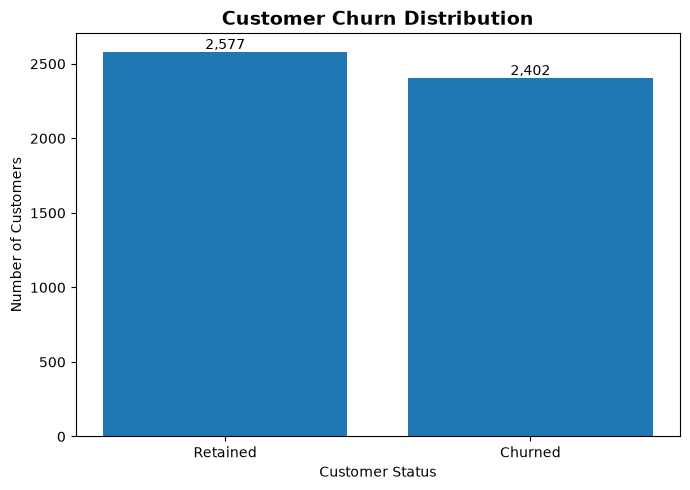

Saved: reports/figures/01_churn_distribution.png


In [2]:
# Figure 1: Customer Churn Distribution

churn_counts = churn_df["Churn"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["Retained", "Churned"],
    [churn_counts.get(0, 0), churn_counts.get(1, 0)]
)

plt.title("Customer Churn Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

# Add counts above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "01_churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: reports/figures/01_churn_distribution.png")